In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_2634.jpg', 'with_mask_3522.jpg', 'with_mask_3491.jpg', 'with_mask_2850.jpg', 'with_mask_2453.jpg']
['with_mask_773.jpg', 'with_mask_1528.jpg', 'with_mask_951.jpg', 'with_mask_964.jpg', 'with_mask_2548.jpg']


In [8]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_2733.jpg', 'without_mask_3069.jpg', 'without_mask_2257.jpg', 'without_mask_652.jpg', 'without_mask_3739.jpg']
['without_mask_20.jpg', 'without_mask_3754.jpg', 'without_mask_858.jpg', 'without_mask_3622.jpg', 'without_mask_773.jpg']


In [9]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [10]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [11]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [12]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [13]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


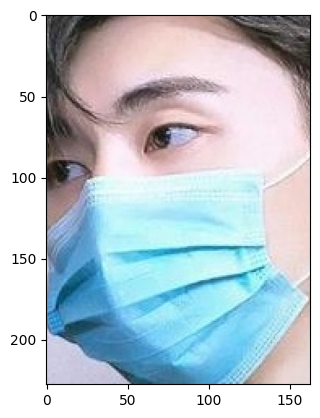

In [14]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

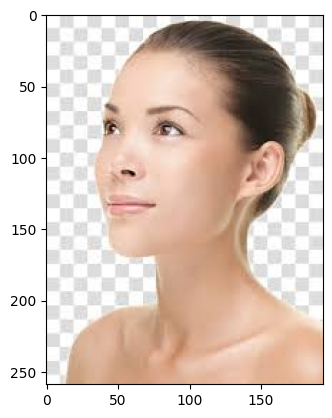

In [15]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [16]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)

list

In [18]:
len(data)

7553

array([[[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [214, 215, 206],
        [223, 224, 218],
        [ 90,  90,  87]],

       [[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [213, 213, 204],
        [223, 224, 218],
        [ 90,  90,  87]],

       [[206, 197, 180],
        [206, 197, 180],
        [207, 198, 181],
        ...,
        [211, 211, 202],
        [223, 224, 218],
        [ 90,  90,  87]],

       ...,

       [[197, 186, 190],
        [197, 186, 190],
        [196, 185, 189],
        ...,
        [231, 213, 196],
        [238, 226, 214],
        [103,  93,  86]],

       [[210, 199, 203],
        [209, 198, 202],
        [207, 196, 200],
        ...,
        [232, 212, 195],
        [239, 224, 213],
        [103,  93,  85]],

       [[211, 202, 205],
        [210, 201, 204],
        [207, 198, 201],
        ...,
        [231, 206, 187],
        [241, 220, 204],
        [104,  87,  78]]], dtype=uint8)
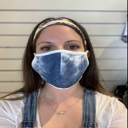

In [19]:
data[0]

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape

(128, 128, 3)

In [22]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [23]:
type(X)

numpy.ndarray

In [24]:
type(Y)

numpy.ndarray

In [25]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [27]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [28]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[247, 243, 206],
        [246, 242, 205],
        [245, 241, 204],
        ...,
        [244, 241, 222],
        [245, 242, 224],
        [245, 242, 225]],

       [[244, 240, 203],
        [244, 240, 203],
        [244, 240, 203],
        ...,
        [240, 237, 218],
        [242, 239, 222],
        [244, 241, 224]],

       [[244, 238, 202],
        [244, 238, 202],
        [245, 239, 203],
        ...,
        [239, 236, 217],
        [241, 238, 220],
        [242, 239, 222]],

       ...,

       [[254, 252, 234],
        [253, 250, 232],
        [250, 249, 229],
        ...,
        [255, 251, 246],
        [253, 250, 248],
        [252, 249, 248]],

       [[255, 254, 237],
        [254, 252, 234],
        [251, 250, 230],
        ...,
        [255, 252, 247],
        [255, 253, 250],
        [255, 254, 252]],

       [[255, 255, 238],
        [254, 253, 235],
        [252, 251, 231],
        ...,
        [255, 252, 249],
        [254, 252, 250],
        [253, 253, 251]]], dtype=uint8)
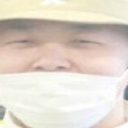

In [29]:
X_train[0]

In [30]:
X_train_scaled[0]

array([[[0.96862745, 0.95294118, 0.80784314],
        [0.96470588, 0.94901961, 0.80392157],
        [0.96078431, 0.94509804, 0.8       ],
        ...,
        [0.95686275, 0.94509804, 0.87058824],
        [0.96078431, 0.94901961, 0.87843137],
        [0.96078431, 0.94901961, 0.88235294]],

       [[0.95686275, 0.94117647, 0.79607843],
        [0.95686275, 0.94117647, 0.79607843],
        [0.95686275, 0.94117647, 0.79607843],
        ...,
        [0.94117647, 0.92941176, 0.85490196],
        [0.94901961, 0.9372549 , 0.87058824],
        [0.95686275, 0.94509804, 0.87843137]],

       [[0.95686275, 0.93333333, 0.79215686],
        [0.95686275, 0.93333333, 0.79215686],
        [0.96078431, 0.9372549 , 0.79607843],
        ...,
        [0.9372549 , 0.9254902 , 0.85098039],
        [0.94509804, 0.93333333, 0.8627451 ],
        [0.94901961, 0.9372549 , 0.87058824]],

       ...,

       [[0.99607843, 0.98823529, 0.91764706],
        [0.99215686, 0.98039216, 0.90980392],
        [0.98039216, 0

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [32]:
num_of_classes = 2

# Define the CNN Model
class FaceMaskCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(FaceMaskCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # Calculate the flattened size after conv layers
        # Input: 128x128 -> Conv1: 126x126 -> Pool: 63x63 -> Conv2: 61x61 -> Pool: 30x30
        self.flatten_size = 64 * 30 * 30

        self.fc1 = nn.Linear(self.flatten_size, 128)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, self.flatten_size)
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

model = FaceMaskCNN(num_of_classes).to(device)
print(model)

FaceMaskCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=57600, out_features=128, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


In [33]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Prepare data for PyTorch (convert from NHWC to NCHW format)
X_train_tensor = torch.FloatTensor(X_train_scaled).permute(0, 3, 1, 2)
Y_train_tensor = torch.LongTensor(Y_train)
X_test_tensor = torch.FloatTensor(X_test_scaled).permute(0, 3, 1, 2)
Y_test_tensor = torch.LongTensor(Y_test)

# Split training data for validation (10% validation)
val_size = int(0.1 * len(X_train_tensor))
train_size = len(X_train_tensor) - val_size

train_dataset = TensorDataset(X_train_tensor[:train_size], Y_train_tensor[:train_size])
val_dataset = TensorDataset(X_train_tensor[train_size:], Y_train_tensor[train_size:])
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [34]:
# Training the neural network
num_epochs = 5
history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Store history
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch [1/5], Train Loss: 0.4002, Train Acc: 0.8286, Val Loss: 0.3184, Val Acc: 0.8675
Epoch [2/5], Train Loss: 0.2626, Train Acc: 0.8904, Val Loss: 0.3025, Val Acc: 0.8808
Epoch [3/5], Train Loss: 0.2292, Train Acc: 0.9068, Val Loss: 0.2746, Val Acc: 0.8940
Epoch [4/5], Train Loss: 0.1827, Train Acc: 0.9231, Val Loss: 0.2351, Val Acc: 0.9189
Epoch [5/5], Train Loss: 0.1522, Train Acc: 0.9367, Val Loss: 0.2810, Val Acc: 0.9040


In [35]:
# Model Evaluation
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

accuracy = test_correct / test_total
print(f'Test Accuracy = {accuracy:.4f}')

Test Accuracy = 0.9292


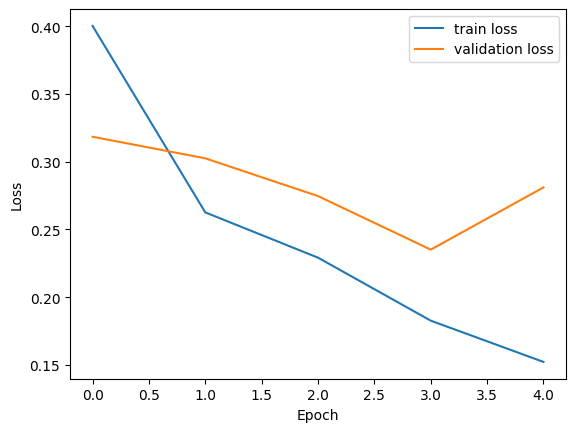

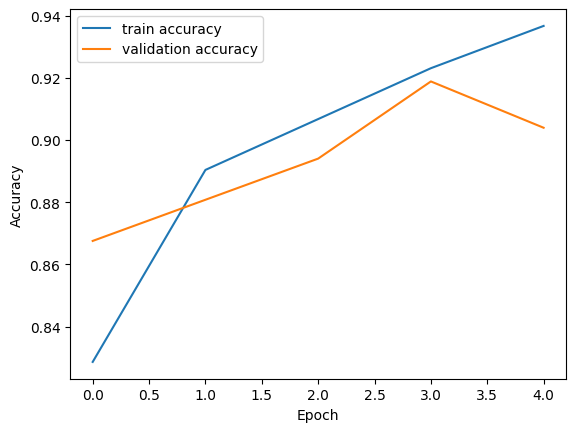

In [36]:
# Plot the loss value
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot the accuracy value
plt.plot(history['acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/test.png


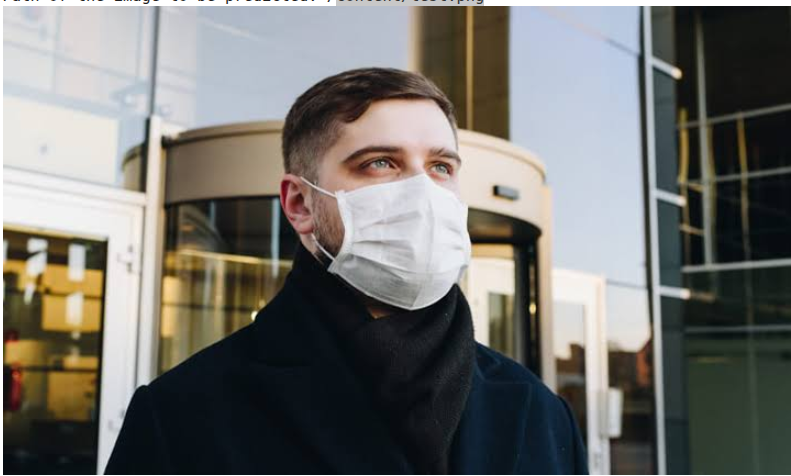

[[0.22500561 0.77499443]]
1
The person in the image is wearing a mask


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128, 128))

input_image_scaled = input_image_resized / 255.0

# Convert to PyTorch tensor (HWC -> CHW format)
input_image_tensor = torch.FloatTensor(input_image_scaled).permute(2, 0, 1).unsqueeze(0).to(device)

# Make prediction
model.eval()
with torch.no_grad():
    input_prediction = model(input_image_tensor)
    probabilities = torch.softmax(input_prediction, dim=1)
    print(probabilities.cpu().numpy())

    input_pred_label = torch.argmax(input_prediction, dim=1).item()
    print(input_pred_label)

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')